# Does home-field novelty anticipate breadth for brand-new phrases? The Frame N confirmation (demo)

This notebook demos **experiment 13** of the project *"Concepts spread once adopters make them their own"*. It is a
**sealed, single-unseal confirmation** of the paper's RQ1 claim on a population that no earlier step had scored.

**The claim under test.** A new concept's early home neighbourhood is the set of topics it co-occurs with in papers
from its home field during its first years. The claim is that when this neighbourhood is **open**, the concept later
spreads **more broadly across fields** than its size and early reach would predict. Open means it keeps picking up new
partners outside its expected community and does not settle into a fixed set of partners.

**Frame N** is the test population. It consists of **vocabulary-free newborn title phrases**, such as *"stent
retriever"*, *"dielectric metasurfaces"* or *"drug shortages"*:
* the phrases were first used in paper titles in 2003–2015;
* none of them is in the 56,643-concept OpenAlex/MAG legacy vocabulary, so a curated vocabulary cannot have
  survivor-selected them;
* all counts come from one pass over the OpenAlex S3 snapshot (2026-09-23);
* outcome counts were **sealed at write time** and unsealed exactly once, after the analysis spec was frozen.

**What is measured**
| symbol | meaning |
|---|---|
| `OPEN_home` | mean of 6 signed, winsorised z-scores of home-field ego-network components in t0−3..t0+2 (constants frozen on 12,499 legacy concepts in EXP5/EXP10) |
| `NOVCHURN_home` | mean(z `NOV_res`, −z `edge_persistence`): *novel partners* plus *partner churn*, the paper's two-component index |
| `O2r_m30` (primary) | **breadth**: rarefied number of distinct OpenAlex fields reached among 30 random papers at t0+6..t0+8 |
| psp | **partial Spearman**: rank x and y, residualise both on a covariate *rung*, then correlate the residuals |
| R0…R5 | covariate ladder: B5 size/growth/reach baselines → contact reach → concept type → early footprint → label coverage → home-group fixed effects |

**Full-run result: the frozen verdict is PARTIAL.**
* OPEN_home is **+0.117 [+0.020, +0.218]** at R3, but +0.086 [−0.009, +0.190] at R5.
* NOVCHURN_home is +0.108 [+0.007, +0.211] at R3.
* The signal is carried by **novelty** (`NOV_res` +0.208), not by churn: `edge_persistence` is null.
* No practical forecasting gain over B5.

**What this notebook runs.** The steps below use the artifact's own code on **all 636 Frame N concepts**. Each
analysis is shown as a figure and compared with the full-run numbers.
1. The `method.py` pipeline driver in plan mode. Its stages need the 476M-row snapshot pass and LLM gate calls, so
   they are not executed.
2. A rebuild of `OPEN_home` / `NOVCHURN_home` from the raw components with the frozen constants.
3. The **outcome**: rarefied field richness from raw per-field counts for 12 concepts, using the exact hypergeometric
   formula.
4. The **rung ladder** R0–R5 with 2,000-draw concept bootstraps, which gives the headline test.
5. **Groups** and DerSimonian–Laird pooling.
6. The **six components**, which show that novelty and not churn carries the signal.
7. **Mechanical coupling**: ALL and SIZEMATCH builds against HOME.
8. The **Cheng et al. (2023) reversal** test.
9. **Holm** correction and the pre-registered **verdict** function.
10. Forecasting gain over B5.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru is not on Colab -> always install (used by the original method.py driver)
_pip('loguru==0.7.3')

# numpy / pandas / scipy / matplotlib are pre-installed on Colab -> install locally only, at Colab's exact versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
These are the import blocks of `method.py` and of the library modules the scoring uses (`lib/rq1stats.py`,
`lib/ladder.py`, `lib/laddern.py`, `lib/scoring.py`). Matplotlib is added for the figures.

In [2]:
# --- method.py (original) ---
from __future__ import annotations

import argparse
import os
import subprocess
import sys
import time
from pathlib import Path

from loguru import logger

# --- lib/rq1stats.py, lib/ladder.py, lib/laddern.py, lib/scoring.py (original) ---
import json
import math

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata

# --- added for the notebook ---
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
C_HOME, C_NOV, C_ALL, C_SZ, C_CH, C_GREY = "#1f77b4", "#d62728", "#ff7f0e", "#2ca02c", "#9467bd", "#7f7f7f"

## Data loading
The data is fetched from the project's GitHub repository, with a fallback to a local `mini_demo_data.json`. The file
holds all 636 Frame N concepts, restricted to the columns the scoring needs. It also holds the frozen OPEN constants,
raw outcome-window field counts for 12 concepts, and the full-run reference numbers.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/main/round-5/experiment-13/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"], "\n")
df = pd.DataFrame(data["examples"])
REF = data["reference_full_run"]
print("concepts:", len(df), "| by analysis group:", data["n_by_group"])
print("primary outcome:", data["primary_outcome"], "| fallback A:", data["fallback_A"])
df[["name", "t0", "agroup", "type", "n_home_early", "OPEN_home", "NOVCHURN_home", "O2r_m30"]].head(8)

EXP13 Frame-N demo data: all 636 vocabulary-free newborn title-phrase concepts (onsets 2003-2015) with the columns the frozen scoring needs (covariates, six ego-network components per build, indices, Cheng measures, unsealed outcomes), raw outcome-window field counts for 12 concepts, the frozen EXP5 OPEN constants and the full-run reference numbers. 

concepts: 636 | by analysis group: {'BGM+Med': 253, 'CS+Eng': 153, 'SOC': 91, 'PHYS': 90, 'LIFEENV': 36, 'MATHDEC': 13}
primary outcome: O2r_m30 | fallback A: {'n_finite_O2r_m50_and_OPEN_home': 397, 'threshold': 800, 'primary_outcome': 'O2r_m30', 'applied': True, 'n_finite_O2r_m30_and_OPEN_home': 448}


,name,t0,agroup,type,n_home_early,OPEN_home,NOVCHURN_home,O2r_m30
0,cell lymphoma patients,2007,BGM+Med,topic,54,0.213288,-0.391240,3.060002
1,interferon free,2012,BGM+Med,topic,83,0.271476,-0.517662,3.530791
2,recycling economy,2004,CS+Eng,topic,51,0.834975,0.268674,6.134511
3,pbpb collisions,2011,PHYS,topic,68,NaN,NaN,1.000000
4,airway scope,2007,BGM+Med,object,60,-0.265756,-1.208182,NaN
5,porous graphene,2012,CS+Eng,object,59,0.190762,-0.938181,4.990315
6,education exam,2006,BGM+Med,topic,108,1.300679,0.879553,2.578947
7,antagonist oral,2014,BGM+Med,object,174,0.437900,-1.131355,1.743939


## Config
These are the scoring parameters, taken from the frozen spec. The full run used **B = 2,000** concept bootstraps for
the headline cells and **1,000** for the secondary cells (per-group, components, clean variants). The seed is
**20260929**. With these values the demo reproduces the full-run point estimates *and* confidence intervals exactly,
and the whole notebook takes about 2 minutes. To make it faster, lower `N_BOOT` and `N_BOOT_MINOR`, for example to
400 and 200. The point estimates stay exact and only the CIs become noisier.

In [5]:
N_BOOT = data["bootstrap"]["B"]              # headline cells (original: 2000)
N_BOOT_MINOR = data["bootstrap"]["B_minor"]  # per-group / component / clean cells (original: min(1000, B))
SEED = data["bootstrap"]["seed"]             # original: 20260929
PRIM = data["primary_outcome"]               # 'O2r_m30' (fallback A fired mechanically: O2r_m50 n = 397 < 800)
print(N_BOOT, N_BOOT_MINOR, SEED, PRIM)

2000 1000 20260929 O2r_m30


## How Frame N was built
The funnel below shows how the 636 concepts were selected from 407k mined title n-grams. The steps up to the
**onset rule** are counting rules on the snapshot. An onset requires N(t0) ≥ 20 and fewer than 25% of N(t0+2) in
each of the three prior years. After that come containment deduplication and a home-field rule. The last cut is an
**LLM precision gate**, which keeps phrases that name a concept and removes named entities, non-English phrases and
fragments. The two bottom bars are the analysis samples: concepts with a finite `OPEN_home`, and the subset that also
has the outcome.

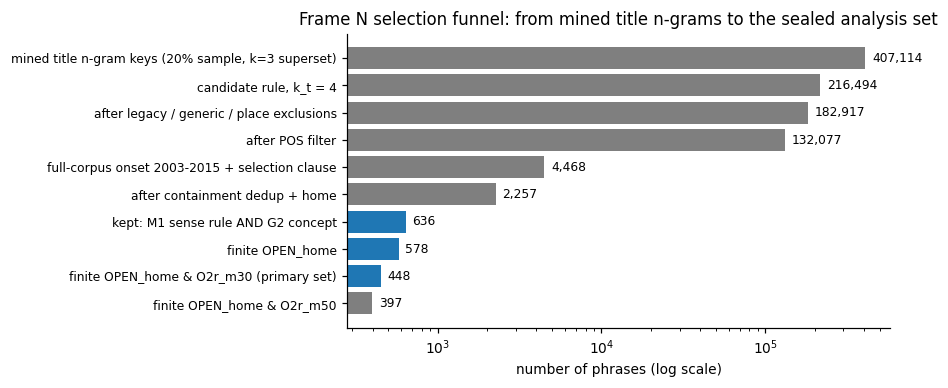

In [6]:
pc = data["pipeline_counts"]
labels = [k for k in pc if not k.startswith("LLM-gated")]
vals = [pc[k] for k in labels]
fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.barh(range(len(vals)), vals, color=[C_GREY] * 6 + [C_HOME] * 3)
ax.set_xscale("log"); ax.invert_yaxis()
ax.set_yticks(range(len(vals)), [l.replace(" (Pass-N candidates)", "") for l in labels], fontsize=8)
for i, v in enumerate(vals):
    ax.text(v * 1.1, i, f"{v:,}", va="center", fontsize=8)
ax.set_xlabel("number of phrases (log scale)")
ax.set_title("Frame N selection funnel: from mined title n-grams to the sealed analysis set")
plt.tight_layout(); plt.show()

## Step 1: the `method.py` pipeline driver
This is the artifact's `method.py`, copied verbatim with one notebook fix: `__file__` does not exist in a notebook, so
`ROOT` is the current directory. The driver chains ten stages, S0–S9, and each stage is a resumable script. By default
it **only prints the plan**, and `--run` executes the stages. The stages need the full snapshot pass (2,040 files,
24.2M verified phrase hits) and paid LLM gate calls, so the demo calls it in plan mode. From Step 2 on, the notebook
re-runs the scoring stages S7–S9 on the frozen feature table.

| stage | what it does |
|---|---|
| S0 | hash-seal the pre-registration and `frozen_spec_v0` |
| S1 | unit tests: ported EXP10 code is exactly equivalent (T1/T4/T8) |
| S2–S3 | mine candidate phrases from a 20% file sample and apply the onset, exclusion and POS rules |
| S4 | full-corpus counts 1995–2022; outcome rows are **sealed at write time** |
| S5 | onset detection, dedup, home field, LLM precision gate |
| S6 | features: B5, reach, footprint, ego-network builds, Cheng measures, clean variants |
| S7 | indices, pre-seal diagnostics, fallback E, power, **FREEZE** |
| S8 | the **single unseal** and frozen scoring (a second unseal is refused) |
| S9 | independent audit, figures, `method_out.json` |

In [7]:
"""Frame-N confirmation pipeline driver (docstring shortened; see the artifact's method.py)."""
ROOT = Path.cwd()   # notebook fix: original was Path(__file__).resolve().parent
PY = str(ROOT / ".venv" / "bin" / "python")
STAGES = [
    ("S0", [["s0_prereg.py"]]),
    ("S1", [["tests/unit_tests_port.py"], ["tests/unit_tests_new.py"]]),
    ("S2", [["passM.py", "--workers", "9"], ["passM.py", "--merge", "--workers", "6"]]),
    ("S3", [["s3_candidates.py", "--stage", "all"]]),
    ("S4", [["passN.py", "--workers", "9"], ["passN.py", "--merge"]]),
    ("S5", [["s5_onset.py"], ["s5_gate.py", "estimate"], ["s5_gate.py", "run"], ["s5_gate.py", "m2", "--m2all"],
            ["s5_gate.py", "sheet"], ["s5_gate.py", "score"], ["s5_gate.py", "m2rest"], ["s5_gate.py", "sheet2"],
            ["s5_gate2.py", "eval"], ["s5_gate2.py", "run"], ["s5_gate2.py", "frame"]]),
    ("S6", [["s6_features.py", "--workers", "9"]]),
    ("S7", [["s7_freeze.py", "prepare"], ["s7_freeze.py", "power"], ["s8_unseal.py", "--dryrun"],
            ["s7_freeze.py", "freeze"]]),
    ("S8", [["s8_unseal.py"]]),
    ("S9", [["audit_frame_n.py"], ["make_outputs_n.py"]]),
]


@logger.catch(reraise=True)
def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--from", dest="start", default="S0")
    ap.add_argument("--to", dest="end", default="S9")
    ap.add_argument("--run", action="store_true")
    a = ap.parse_args()
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    (ROOT / "logs").mkdir(exist_ok=True)
    logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")
    names = [s for s, _ in STAGES]
    todo = STAGES[names.index(a.start):names.index(a.end) + 1]
    env = dict(os.environ, PYTHONPATH=str(ROOT / "lib"), OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1",
               MKL_NUM_THREADS="1")
    for stage, cmds in todo:
        for c in cmds:
            logger.info(f"{stage}: {' '.join(c)}")
            if not a.run:
                continue
            t = time.time()
            r = subprocess.run([PY, *c], cwd=ROOT, env=env)
            if r.returncode != 0:
                logger.error(f"{stage} failed ({' '.join(c)}), exit {r.returncode}")
                raise SystemExit(r.returncode)
            logger.info(f"{stage} ok in {(time.time() - t) / 60:.1f} min")

In [8]:
# notebook fix: argparse reads sys.argv (the kernel's arguments in Jupyter) -> emulate `python method.py` (plan only)
_argv = sys.argv
sys.argv = ["method.py"]
main()
sys.argv = _argv
logger.remove()

11:44:59|INFO   |S0: s0_prereg.py


11:44:59|INFO   |S1: tests/unit_tests_port.py


11:44:59|INFO   |S1: tests/unit_tests_new.py


11:44:59|INFO   |S2: passM.py --workers 9


11:44:59|INFO   |S2: passM.py --merge --workers 6


...

11:45:00|INFO   |S7: s8_unseal.py --dryrun


11:45:00|INFO   |S7: s7_freeze.py freeze


11:45:00|INFO   |S8: s8_unseal.py


11:45:00|INFO   |S9: audit_frame_n.py


11:45:00|INFO   |S9: make_outputs_n.py


## Step 2: rebuilding the indices from raw components (`lib/ladder.py`, `s7_freeze.py`)
Each concept has six **ego-network components**. They are computed separately for three builds of its early
co-occurrence network:
* **HOME** uses home-field papers only;
* **ALL** uses all papers;
* **SIZEMATCH** uses all papers subsampled to the home count.

| component | sign | meaning |
|---|---|---|
| `new_edge_rate` | + | share of neighbour topics that are new each year |
| `n_comm_W3` | + | number of communities among the neighbours |
| `participation` | + | how evenly the neighbours spread across communities |
| `NOV_res` | + | **novel partners**: neighbours outside the concept's expected community (residualised) |
| `ego_density_W3` | − | a dense, closed neighbourhood counts against openness |
| `edge_persistence` | − | **churn**: partners that persist year to year count against openness |

`zw()` clips a component to the frozen `[lo, hi]` range, z-scores it with the frozen EXP5 `mu`/`sd` (fitted on 12,499
legacy concepts, *not* on Frame N) and applies the sign. `OPEN_b` is the mean of the finite z-scores. It needs ≥ 4 of
the 6, and the HOME and SIZEMATCH builds also need ≥ 10 early home papers. `NOVCHURN_home` averages only the novelty
and churn terms. The check below compares the rebuilt values with the stored frozen table.

In [9]:
COMPONENTS = ["new_edge_rate", "n_comm_W3", "participation", "NOV_res", "ego_density_W3", "edge_persistence"]
MIN_HOME_PAPERS = data["open_min_home_papers"]


def open_score(df: pd.DataFrame, build: str, const: dict, min_home: int = MIN_HOME_PAPERS,
               min_comp: int = 4) -> tuple[np.ndarray, pd.DataFrame]:
    '''OPEN_b (NaN unless >= min_comp of 6 z-scores finite; HOME/SIZEMATCH NaN if < min_home home papers t0..t0+2).'''
    Z = pd.DataFrame(index=df.index)
    for k in COMPONENTS:
        c = const[k]
        v = df[f"{k}__{build}"].to_numpy(float)
        Z[k] = c["sign"] * (np.clip(v, c["lo"], c["hi"]) - c["mu"]) / c["sd"]
    nfin = np.isfinite(Z.to_numpy()).sum(1)
    with np.errstate(invalid="ignore"):
        o = np.nanmean(np.where(np.isfinite(Z.to_numpy()), Z.to_numpy(), np.nan), axis=1)
    o[nfin < min_comp] = np.nan
    if build in ("home", "sizematch"):
        o[df["n_home_early"].to_numpy() < min_home] = np.nan
    return o, Z


def zw(v: np.ndarray, c: dict) -> np.ndarray:
    return c["sign"] * (np.clip(v, c["lo"], c["hi"]) - c["mu"]) / c["sd"]


oc = data["frozen_open_constants"]
df = df.astype({c: float for c in df.columns if c.split("__")[0] in COMPONENTS})
rebuilt = {}
for b in ("home", "all", "sizematch"):
    rebuilt[f"OPEN_{b}"], _ = open_score(df, b, oc[b], min_comp=data["open_min_components"])
h = oc["home"]
a_, b_ = zw(df["NOV_res__home"].to_numpy(float), h["NOV_res"]), zw(df["edge_persistence__home"].to_numpy(float), h["edge_persistence"])
nv = (a_ + b_) / 2
nv[~(np.isfinite(a_) & np.isfinite(b_) & (df.n_home_early.to_numpy() >= MIN_HOME_PAPERS))] = np.nan
rebuilt["NOVCHURN_home"] = nv
for k, v in rebuilt.items():
    stored = df[k].to_numpy(float)
    same_nan = np.array_equal(np.isnan(v), np.isnan(stored))
    print(f"{k:15s} finite n = {np.isfinite(v).sum():3d}   max |rebuilt - frozen| = {np.nanmax(np.abs(v - stored)):.1e}   "
          f"same missingness: {same_nan}")

OPEN_home       finite n = 578   max |rebuilt - frozen| = 0.0e+00   same missingness: True
OPEN_all        finite n = 631   max |rebuilt - frozen| = 0.0e+00   same missingness: True
OPEN_sizematch  finite n = 587   max |rebuilt - frozen| = 0.0e+00   same missingness: True
NOVCHURN_home   finite n = 563   max |rebuilt - frozen| = 0.0e+00   same missingness: True


The figure shows what the index is made of. Panel (a) plots the 578 concepts with a finite `OPEN_home` against the
primary outcome. Panel (b) shows the frozen EXP5 constants at work: the distribution of each signed z-score on
Frame N. A z-score of 0 means "as open as the average legacy concept", and higher values mean more open.

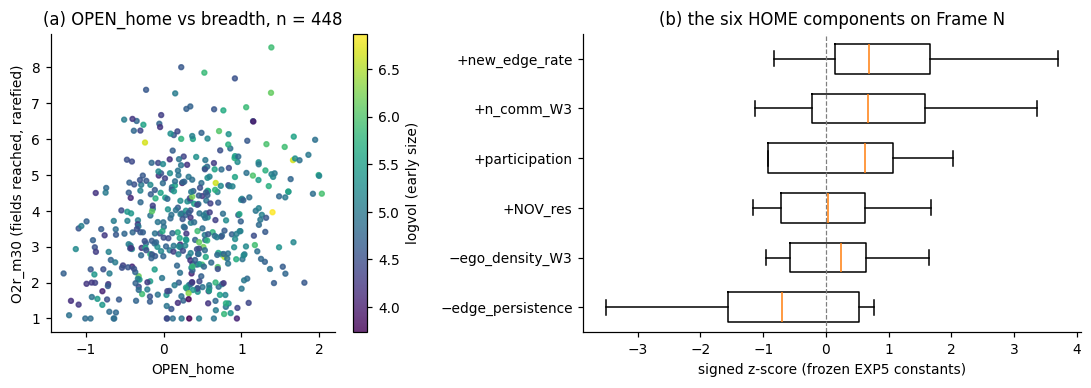

In [10]:
_, Zh = open_score(df, "home", oc["home"])
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1, 1.4]})
m = np.isfinite(df.OPEN_home) & np.isfinite(df[PRIM])
sc = ax[0].scatter(df.OPEN_home[m], df[PRIM][m], c=df.logvol[m], cmap="viridis", s=10, alpha=.8)
plt.colorbar(sc, ax=ax[0], label="logvol (early size)")
ax[0].set_xlabel("OPEN_home"); ax[0].set_ylabel(f"{PRIM} (fields reached, rarefied)")
ax[0].set_title(f"(a) OPEN_home vs breadth, n = {m.sum()}")
ok = df.n_home_early >= MIN_HOME_PAPERS
ax[1].boxplot([Zh.loc[ok, k].dropna() for k in COMPONENTS], vert=False, widths=.6, showfliers=False)
ax[1].set_yticks(range(1, 7), [f"{'−' if oc['home'][k]['sign'] < 0 else '+'}{k}" for k in COMPONENTS])
ax[1].axvline(0, color=C_GREY, lw=.8, ls="--")
ax[1].invert_yaxis()
ax[1].set_xlabel("signed z-score (frozen EXP5 constants)")
ax[1].set_title("(b) the six HOME components on Frame N")
plt.tight_layout(); plt.show()

## Step 3: the outcome, rarefied field richness (`audit_frame_n.py`)
**Breadth** is measured in the outcome window t0+6..t0+8, or t0+5..t0+7 for the 2015 onsets. It is based on how many
of the phrase's papers fall in each of the 26 OpenAlex fields. Raw field counts grow with volume, so the outcome is
*rarefied*: it is the expected number of distinct fields among **m** papers drawn at random without replacement. For
a field with n_j of the N papers, the probability that the field appears in the draw is 1 − P(none drawn), which is a
hypergeometric term:

$$O2r_m = \sum_j \Big[1 - \frac{\binom{N-n_j}{m}}{\binom{N}{m}}\Big]$$

The outcome is undefined if N < m. The pre-registered primary outcome was m = 50. Only 397 concepts had both a finite
O2r_m50 and a finite OPEN_home, below the threshold of 800. Fallback A therefore fired **mechanically** and switched
the primary outcome to **m = 30** (n = 448).

The cell below recomputes both outcomes from the **raw unsealed per-field counts** for 12 concepts that span the
outcome range. It uses the audit's independent `scipy.stats.hypergeom` code path.

In [11]:
def rarefied_hypergeom(counts, m: int) -> float:
    counts = np.asarray([c for c in counts if c > 0], int)
    N = int(counts.sum())
    if N < m:
        return float("nan")
    return float(sum(1 - stats.hypergeom(N, int(nj), m).pmf(0) for nj in counts))


rows = []
for r in data["rarefaction_examples"]:
    cnt = list(r["field_counts"].values())
    rows.append({"phrase": r["name"], "t0": r["t0"], "window": f"{r['window'][0]}-{r['window'][1]}",
                 "papers N": sum(cnt), "fields hit": len(cnt),
                 "O2r_m50 (demo)": rarefied_hypergeom(cnt, 50), "O2r_m50 (frozen)": r["O2r_m50"],
                 "O2r_m30 (demo)": rarefied_hypergeom(cnt, 30), "O2r_m30 (frozen)": r["O2r_m30"]})
rar = pd.DataFrame(rows)
print("max |demo - frozen| O2r_m50:", f"{np.nanmax(np.abs(rar['O2r_m50 (demo)'] - rar['O2r_m50 (frozen)'])):.1e}",
      "| O2r_m30:", f"{np.nanmax(np.abs(rar['O2r_m30 (demo)'] - rar['O2r_m30 (frozen)'])):.1e}")
rar.round(3)

max |demo - frozen| O2r_m50: 1.3e-12 | O2r_m30: 9.9e-13


,phrase,t0,window,papers N,fields hit,O2r_m50 (demo),O2r_m50 (frozen),O2r_m30 (demo),O2r_m30 (frozen)
0,materi fluida,2014,2020-2022,106,1,1.000,1.000,1.000,1.000
1,sequence of pseudomonas,2012,2018-2020,59,2,1.979,1.979,1.763,1.763
2,stent retriever,2013,2019-2021,178,5,2.530,2.530,1.956,1.956
3,island methylator phenotype,2006,2012-2014,54,3,3.000,3.000,2.966,2.966
4,pcsk9 inhibitors,2015,2020-2022,269,7,3.432,3.432,2.650,2.650
5,dielectric metasurfaces,2015,2020-2022,359,5,3.839,3.839,3.552,3.552
6,dynamic spectrum,2007,2013-2015,200,7,4.341,4.341,3.665,3.665
7,metal dichalcogenides,2013,2019-2021,1231,8,4.828,4.828,4.394,4.394
8,drug shortages,2011,2017-2019,70,6,5.350,5.350,4.501,4.501
9,modified particle,2006,2012-2014,96,8,5.928,5.928,4.713,4.713


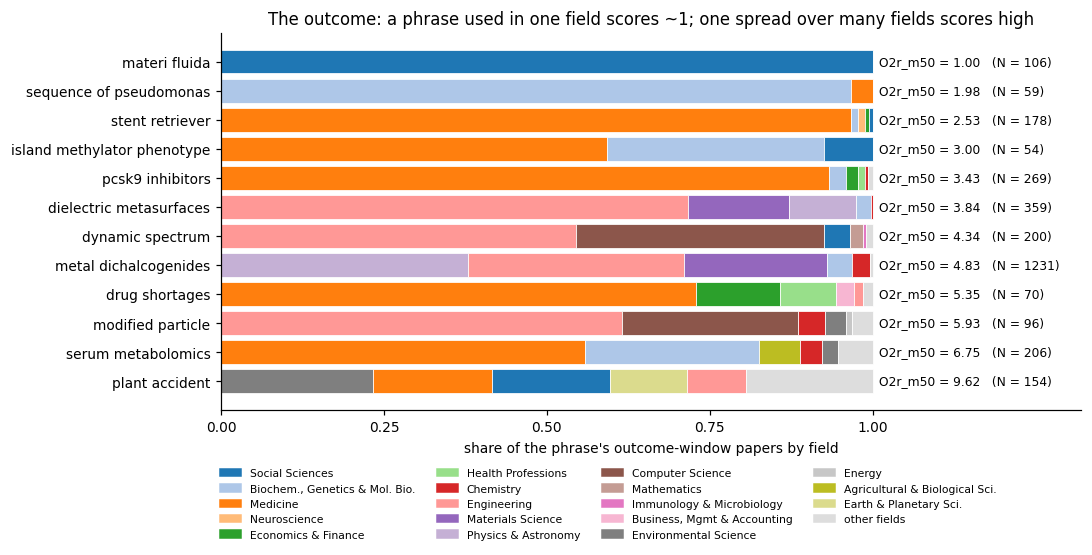

In [12]:
# Each bar is one phrase's papers in the outcome window, split by field (top 5 fields + rest); label = rarefied breadth.
ex = data["rarefaction_examples"]
fig, ax = plt.subplots(figsize=(10, 5.2))
cmap = plt.get_cmap("tab20")
field_color = {}
for i, r in enumerate(ex):
    cnt = pd.Series(r["field_counts"]); tot = cnt.sum()
    left = 0.0
    for f, v in list(cnt.items())[:5]:
        col = field_color.setdefault(f, cmap(len(field_color) % 20))
        ax.barh(i, v / tot, left=left, color=col, edgecolor="white", lw=.5)
        left += v / tot
    ax.barh(i, 1 - left, left=left, color="#dddddd", edgecolor="white", lw=.5)
    ax.text(1.01, i, f"O2r_m50 = {r['O2r_m50']:.2f}   (N = {tot})", va="center", fontsize=8)
ax.set_yticks(range(len(ex)), [r["name"] for r in ex]); ax.invert_yaxis()
ax.set_xlim(0, 1.32); ax.set_xticks([0, .25, .5, .75, 1])
ax.set_xlabel("share of the phrase's outcome-window papers by field")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in field_color.values()] + [plt.Rectangle((0, 0), 1, 1, color="#dddddd")]
ax.legend(handles, list(field_color) + ["other fields"], fontsize=7, ncol=4, loc="upper center",
          bbox_to_anchor=(0.45, -0.13), frameon=False)
ax.set_title("The outcome: a phrase used in one field scores ~1; one spread over many fields scores high")
plt.tight_layout(); plt.show()

## Step 4: the scoring machinery (`lib/rq1stats.py`, `lib/ladder.py`, `lib/laddern.py`)
This code is copied unchanged from the artifact.

* `psp_point` is the **partial Spearman**. It rank-transforms x, y and the continuous covariates, residualises the
  ranks of x and y on [1, ranked covariates, dummies] by least squares, and returns the Pearson correlation of the
  residuals.
* `psp_boot2` runs a **concept bootstrap with refit**. Each draw resamples concepts, recomputes the ranks and the
  residualisation, and drops dummies that become constant. It returns the 95% percentile CI and a one-sided p in the
  pre-registered direction.
* `rung_design` builds the Frame N covariate **ladder**:

| rung | adds |
|---|---|
| R0 | B5 = log early volume, growth, off-home share, field entropy, reach (ranked) + onset-year dummies (+ 2015 window flag) |
| R1 | + CONTACT_REACH (fields the concept's early co-authors publish in) |
| R2 | + LLM concept type (method / object / property / unlabelled) + generic flag |
| R3 | + footprint before onset (log N, n fields, re-emergence flag) (**primary rung**) |
| R4 | + early label coverage and home coverage |
| R5 | + home-group fixed effects |

* `dersimonian_laird` pools the per-group estimates with a random-effects model. `holm` is the Holm step-down
  correction. `paired_diff` is a paired bootstrap of the difference between two indices' psp values on a common sample.

In [13]:
# ----------------------------------------------------------------------------- lib/rq1stats.py
def _resid(Z: np.ndarray, Y: np.ndarray) -> np.ndarray:
    beta, *_ = np.linalg.lstsq(Z, Y, rcond=None)
    return Y - Z @ beta


def psp_point(x: np.ndarray, y: np.ndarray, B: np.ndarray, cat: np.ndarray | None) -> float:
    """Pearson(resid(rank x ~ rank B + cat dummies), resid(rank y ~ same)). Rows must be complete."""
    Zc = [np.ones((len(x), 1))]
    if B is not None and B.shape[1]:
        Zc.append(rankdata(B, axis=0))
    if cat is not None and cat.shape[1]:
        Zc.append(cat)
    Z = np.hstack(Zc)
    R = _resid(Z, np.c_[rankdata(x), rankdata(y)])
    sx, sy = R[:, 0].std(), R[:, 1].std()
    if sx <= 1e-12 or sy <= 1e-12:
        return float("nan")
    return float(np.corrcoef(R[:, 0], R[:, 1])[0, 1])


def dersimonian_laird(b, se) -> dict:
    """EXP6 lib/stats_core.dersimonian_laird (verbatim logic)."""
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    k = len(b)
    if k == 0:
        return {"k": 0, "b": float("nan"), "se": float("nan"), "ci": [float("nan")] * 2, "p": float("nan"),
                "tau2": float("nan"), "I2": float("nan"), "Q": float("nan")}
    w = 1 / se**2
    bf = (w * b).sum() / w.sum()
    Q = float((w * (b - bf) ** 2).sum())
    Cc = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / Cc) if k > 1 and Cc > 0 else 0.0
    ws = 1 / (se**2 + tau2)
    bre = (ws * b).sum() / ws.sum()
    sre = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    return {"k": k, "b": float(bre), "se": sre, "ci": [float(bre - 1.96 * sre), float(bre + 1.96 * sre)],
            "p": float(2 * stats.norm.sf(abs(bre / sre))), "tau2": float(tau2), "Q": Q, "I2": float(I2)}


def holm(p: list[float]) -> list[float]:
    p = np.asarray(p, float)
    out = np.full(len(p), np.nan)
    ok = np.isfinite(p)
    idx = np.nonzero(ok)[0]
    m = len(idx)
    order = idx[np.argsort(p[idx])]
    run = 0.0
    for r, i in enumerate(order):
        run = max(run, min(1.0, (m - r) * p[i]))
        out[i] = run
    return out.tolist()


# ----------------------------------------------------------------------------- lib/ladder.py
def psp_boot2(x: np.ndarray, y: np.ndarray, B: np.ndarray, C: np.ndarray, n_boot: int, seed: int,
              direction: int = 1, idx_boot: np.ndarray | None = None) -> dict:
    ok = np.isfinite(x) & np.isfinite(y) & np.all(np.isfinite(B), 1) & np.all(np.isfinite(C), 1)
    x, y, B, C = x[ok], y[ok], B[ok], C[ok]
    n = len(x)
    if n < 30 or np.unique(x).size < 3:
        return {"n": int(n), "rho": math.nan, "ci": [math.nan, math.nan], "se": math.nan, "p_one": math.nan,
                "p_two": math.nan, "boot": np.array([])}
    est = psp_point(x, y, B, C)
    rng = np.random.default_rng(seed)
    bs = np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        Ci = C[i]
        keep = Ci.std(0) > 0 if Ci.shape[1] else np.zeros(0, bool)
        bs[b] = psp_point(x[i], y[i], B[i], Ci[:, keep])
    bs = bs[np.isfinite(bs)]
    lo, hi = np.percentile(bs, [2.5, 97.5])
    p_one = float((np.sum(direction * bs <= 0) + 1) / (len(bs) + 1))
    z = np.arctanh(np.clip(bs, -0.999999, 0.999999))
    se_z = float(np.std(z, ddof=1))
    ze = math.atanh(max(min(est, 0.999999), -0.999999))
    return {"n": int(n), "rho": float(est), "ci": [float(lo), float(hi)], "se": float(np.std(bs, ddof=1)),
            "p_one": p_one, "p_two": float(2 * stats.norm.sf(abs(ze / se_z))) if se_z > 0 else math.nan,
            "boot": bs}


# ----------------------------------------------------------------------------- lib/laddern.py
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
RUNGS = ["R0", "R1", "R2", "R3", "R4", "R5"]
POOL_GROUPS = ["CS+Eng", "BGM+Med", "PHYS", "LIFEENV", "SOC"]
REF_YEAR = 2008


def year_dummies(df: pd.DataFrame) -> pd.DataFrame:
    ys = [y for y in sorted(df.t0.unique()) if y != REF_YEAR]
    return pd.DataFrame({f"t0_{y}": (df.t0 == y).astype(float) for y in ys}, index=df.index)


def type_dummies(df: pd.DataFrame) -> pd.DataFrame:
    t = df["type"].fillna("unlabelled")
    return pd.DataFrame({f"type_{c}": (t == c).astype(float) for c in ("method", "object", "property", "unlabelled")},
                        index=df.index)


def group_dummies(df: pd.DataFrame) -> pd.DataFrame:
    gs = [g for g in sorted(df.agroup.dropna().unique()) if g != "BGM+Med"]
    return pd.DataFrame({f"g_{g}": (df.agroup == g).astype(float) for g in gs}, index=df.index)


def rung_design(df: pd.DataFrame, rung: str, drop_type: bool = False, drop_group: bool = False,
                type_generic_only: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    r = RUNGS.index(rung)
    cont = list(B5)
    cat = [year_dummies(df)]
    if "window_flag" in df.columns and df.window_flag.nunique() > 1:
        cat.append(df[["window_flag"]].astype(float))
    if r >= 1:
        cont.append("CONTACT_REACH")
    if r >= 2:
        if not drop_type and not type_generic_only:
            cat.append(type_dummies(df))
        cat.append(df[["generic"]].astype(float))
    if r >= 3:
        cont += ["fp_logN", "fp_nfields"]
        if "fp_reemerge" in df.columns:          # D_fp_reemerge: not constant in Frame N (EXP10 R3 column)
            cat.append(df[["fp_reemerge"]].astype(float))
    if r >= 4:
        cont += ["label_coverage_early", "home_coverage_early"]
    if r >= 5 and not drop_group:
        cat.append(group_dummies(df))
    C = pd.concat(cat, axis=1) if cat else pd.DataFrame(index=df.index)
    C = C.loc[:, C.std() > 0] if len(C) > 1 else C
    Bc = df[cont]
    Bc = Bc.loc[:, Bc.std() > 0] if len(Bc) > 1 else Bc
    return Bc, C


def psp_df(df: pd.DataFrame, xcol: str, ycol: str, rung: str, n_boot: int, seed: int, direction: int = 1,
           keep_boot: bool = False, **kw) -> dict:
    Bc, Cc = rung_design(df, rung, **kw)
    r = psp_boot2(df[xcol].to_numpy(float), df[ycol].to_numpy(float), Bc.to_numpy(float), Cc.to_numpy(float),
                  n_boot, seed, direction)
    r.update({"x": xcol, "y": ycol, "rung": rung, "resampling_unit": "concept", "n_boot": n_boot})
    if not keep_boot:
        r.pop("boot", None)
    return r


def paired_diff(df: pd.DataFrame, xa: str, xb: str, ycol: str, rung: str, n_boot: int, seed: int) -> dict:
    """Paired concept bootstrap of psp(xa) - psp(xb) on the common sample (one-sided p for > 0)."""
    Bc, Cc = rung_design(df, rung)
    B, C = Bc.to_numpy(float), Cc.to_numpy(float)
    xa_, xb_, y = df[xa].to_numpy(float), df[xb].to_numpy(float), df[ycol].to_numpy(float)
    ok = np.isfinite(xa_) & np.isfinite(xb_) & np.isfinite(y) & np.all(np.isfinite(B), 1)
    xa_, xb_, y, B, C = xa_[ok], xb_[ok], y[ok], B[ok], C[ok]
    n = len(y)
    if n < 30:
        return {"n": int(n), "diff": math.nan, "ci": [math.nan, math.nan], "p_one": math.nan}
    est = psp_point(xa_, y, B, C) - psp_point(xb_, y, B, C)
    rng = np.random.default_rng(seed)
    bs = []
    for _ in range(n_boot):
        i = rng.integers(0, n, n)
        Ci = C[i]
        keep = Ci.std(0) > 0
        bs.append(psp_point(xa_[i], y[i], B[i], Ci[:, keep]) - psp_point(xb_[i], y[i], B[i], Ci[:, keep]))
    bs = np.asarray(bs)
    bs = bs[np.isfinite(bs)]
    return {"n": int(n), "a": xa, "b": xb, "y": ycol, "rung": rung, "diff": float(est),
            "ci": [float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))],
            "p_one": float((np.sum(bs <= 0) + 1) / (len(bs) + 1)), "resampling_unit": "concept", "n_boot": n_boot}


def per_group(df: pd.DataFrame, xcol: str, ycol: str, rung: str, n_boot: int, seed: int, direction: int = 1) -> dict:
    rows = {}
    for gi, g in enumerate(POOL_GROUPS + ["MATHDEC"]):
        d = df[df.agroup == g]
        rows[g] = psp_df(d, xcol, ycol, rung, n_boot, seed + 101 * gi, direction, drop_group=True)
    est = [g for g in POOL_GROUPS if rows[g]["n"] >= 30 and np.isfinite(rows[g]["rho"])]
    b = [rows[g]["rho"] for g in est]
    se = [rows[g]["se"] for g in est]
    dl = dersimonian_laird(b, se) if len(est) >= 2 else {}
    logo = {}
    for g in est:
        o = [h for h in est if h != g]
        if len(o) >= 2:
            logo[g] = dersimonian_laird([rows[h]["rho"] for h in o], [rows[h]["se"] for h in o])
    pos = int(sum(1 for v in b if v > 0))
    return {"groups": rows, "estimable": est, "n_estimable": len(est), "DL": dl, "n_positive": pos,
            "leave_one_group_out": logo, "x": xcol, "y": ycol, "rung": rung}


# ----------------------------------------------------------------------------- lib/scoring.py (two helpers)
def psp_custom(df: pd.DataFrame, x: str, y: str, cont: list[str], n_boot: int, seed: int, direction: int = 1) -> dict:
    B = df[cont].to_numpy(float) if cont else np.zeros((len(df), 0))
    r = psp_boot2(df[x].to_numpy(float), df[y].to_numpy(float), B, np.zeros((len(df), 0)), n_boot, seed, direction)
    r.pop("boot", None)
    r.update({"x": x, "y": y, "covariates": cont, "resampling_unit": "concept", "n_boot": n_boot})
    return r


def spearman_boot(df: pd.DataFrame, x: str, y: str, n_boot: int, seed: int) -> dict:
    a, b = df[x].to_numpy(float), df[y].to_numpy(float)
    ok = np.isfinite(a) & np.isfinite(b)
    a, b = a[ok], b[ok]
    n = len(a)
    if n < 30:
        return {"n": n, "rho": math.nan, "ci": [math.nan, math.nan]}
    rho = float(stats.spearmanr(a, b)[0])
    rng = np.random.default_rng(seed)
    ra, rb = a, b
    bs = []
    for _ in range(n_boot):
        i = rng.integers(0, n, n)
        bs.append(stats.spearmanr(ra[i], rb[i])[0])
    bs = np.asarray(bs, float)
    bs = bs[np.isfinite(bs)]
    return {"n": int(n), "rho": rho, "ci": [float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))],
            "p_one_gt0": float((np.sum(bs <= 0) + 1) / (len(bs) + 1)), "x": x, "y": y, "n_boot": n_boot,
            "resampling_unit": "concept"}

## Step 5: the headline test, the rung ladder
The cell below estimates the psp of `OPEN_home` and `NOVCHURN_home` with the primary outcome at every rung, using
2,000 bootstraps each. It adds two more sets of estimates:
* `OPEN_home` on the originally planned outcome O2r_m50 at R3 and R5;
* the ALL and SIZEMATCH builds at R3.

The `cells` dict uses the full run's cell keys. That lets the demo compare every estimate one to one with
`frame_n_result.json`.

In [14]:
cells, t_start = {}, time.time()
for x in ("OPEN_home", "NOVCHURN_home"):
    for r in RUNGS:
        cells[f"ladder|{x}|{PRIM}|{r}"] = psp_df(df, x, PRIM, r, N_BOOT, SEED)
for r in ("R3", "R5"):
    cells[f"ladder|OPEN_home|O2r_m50|{r}"] = psp_df(df, "OPEN_home", "O2r_m50", r, N_BOOT, SEED)
for x in ("OPEN_all", "OPEN_sizematch"):
    cells[f"ladder|{x}|{PRIM}|R3"] = psp_df(df, x, PRIM, "R3", N_BOOT, SEED)
print(f"{len(cells)} cells in {time.time() - t_start:.0f} s\n")


def fmt(c, key="rho"):
    return f"{c[key]:+.3f} [{c['ci'][0]:+.3f}, {c['ci'][1]:+.3f}]"


lad = pd.DataFrame([{"cell": k.replace("ladder|", ""), "n": v["n"], "demo psp [95% CI]": fmt(v),
                     "full-run psp [95% CI]": fmt(REF["cells"][k]), "p one-sided": round(v["p_one"], 4)}
                    for k, v in cells.items()])
lad

16 cells in 29 s



,cell,n,demo psp [95% CI],full-run psp [95% CI],p one-sided
0,OPEN_home|O2r_m30|R0,448,"+0.157 [+0.063, +0.253]","+0.157 [+0.063, +0.253]",0.0020
1,OPEN_home|O2r_m30|R1,448,"+0.127 [+0.026, +0.229]","+0.127 [+0.026, +0.229]",0.0055
2,OPEN_home|O2r_m30|R2,448,"+0.126 [+0.024, +0.227]","+0.126 [+0.024, +0.227]",0.0070
3,OPEN_home|O2r_m30|R3,448,"+0.117 [+0.020, +0.218]","+0.117 [+0.020, +0.218]",0.0105
4,OPEN_home|O2r_m30|R4,448,"+0.107 [+0.011, +0.211]","+0.107 [+0.011, +0.211]",0.0170
5,OPEN_home|O2r_m30|R5,448,"+0.086 [-0.009, +0.190]","+0.086 [-0.009, +0.190]",0.0375
6,NOVCHURN_home|O2r_m30|R0,435,"+0.106 [+0.004, +0.207]","+0.106 [+0.004, +0.207]",0.0220
7,NOVCHURN_home|O2r_m30|R1,435,"+0.110 [+0.009, +0.212]","+0.110 [+0.009, +0.212]",0.0200
8,NOVCHURN_home|O2r_m30|R2,435,"+0.109 [+0.005, +0.212]","+0.109 [+0.005, +0.212]",0.0205
9,NOVCHURN_home|O2r_m30|R3,435,"+0.108 [+0.007, +0.211]","+0.108 [+0.007, +0.211]",0.0215


**The ladder figure.** Each point is a psp estimate with its 95% bootstrap CI. Moving right adds more covariates. A
signal that shrinks toward 0 as covariates are added is being explained by them. The dashed line is the q95 |psp| of
200 within-group shuffled-outcome placebos from the full run, which marks how big a pure-noise estimate gets.

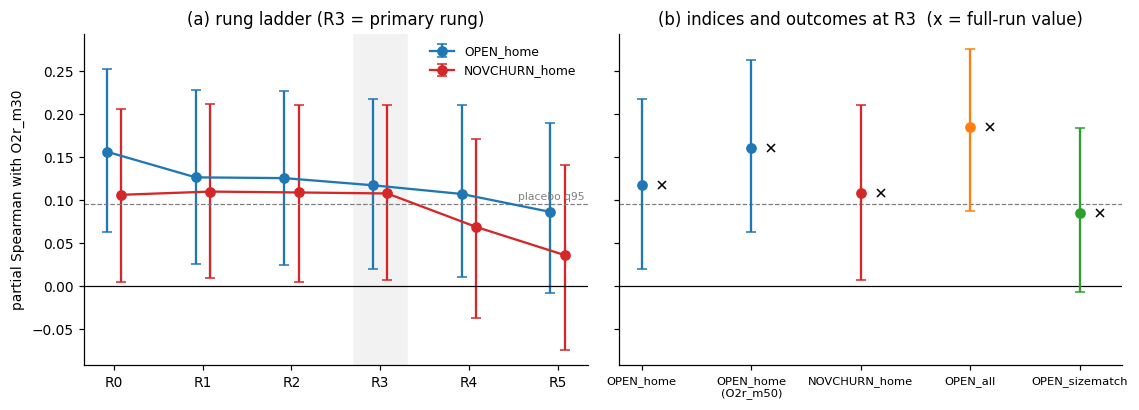

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True)
xs = np.arange(len(RUNGS))
for x, col, off in (("OPEN_home", C_HOME, -0.08), ("NOVCHURN_home", C_NOV, 0.08)):
    est = [cells[f"ladder|{x}|{PRIM}|{r}"]["rho"] for r in RUNGS]
    lo = [cells[f"ladder|{x}|{PRIM}|{r}"]["ci"][0] for r in RUNGS]
    hi = [cells[f"ladder|{x}|{PRIM}|{r}"]["ci"][1] for r in RUNGS]
    ax[0].errorbar(xs + off, est, yerr=[np.subtract(est, lo), np.subtract(hi, est)], fmt="o-", color=col,
                   capsize=3, label=x)
q95 = REF["placebo_planted"]["placebo_within_group_shuffle_OPEN_home"]["q95_abs"]
for a in ax:
    a.axhline(0, color="k", lw=.8); a.axhline(q95, color=C_GREY, ls="--", lw=.8)
ax[0].text(5.3, q95 + .005, "placebo q95", fontsize=7, color=C_GREY, ha="right")
ax[0].set_xticks(xs, RUNGS); ax[0].set_ylabel(f"partial Spearman with {PRIM}")
ax[0].set_title("(a) rung ladder (R3 = primary rung)"); ax[0].legend(frameon=False, fontsize=8)
ax[0].axvspan(2.7, 3.3, color="#f2f2f2", zorder=0)
# (b) builds and outcomes at R3
items = [("OPEN_home", f"ladder|OPEN_home|{PRIM}|R3", C_HOME), ("OPEN_home\n(O2r_m50)", "ladder|OPEN_home|O2r_m50|R3", C_HOME),
         ("NOVCHURN_home", f"ladder|NOVCHURN_home|{PRIM}|R3", C_NOV), ("OPEN_all", f"ladder|OPEN_all|{PRIM}|R3", C_ALL),
         ("OPEN_sizematch", f"ladder|OPEN_sizematch|{PRIM}|R3", C_SZ)]
for i, (lab, k, col) in enumerate(items):
    c = cells[k]
    ax[1].errorbar(i, c["rho"], yerr=[[c["rho"] - c["ci"][0]], [c["ci"][1] - c["rho"]]], fmt="o", color=col, capsize=3)
    ax[1].plot(i + .18, REF["cells"][k]["rho"], "x", color="k", ms=5)
ax[1].set_xticks(range(len(items)), [l for l, _, _ in items], fontsize=7.5)
ax[1].set_title("(b) indices and outcomes at R3  (x = full-run value)")
plt.tight_layout(); plt.show()

**Reading the ladder.**
* `OPEN_home` stays positive at every rung. Its CI excludes 0 from R0 through R4 and just touches 0 at R5, where
  the home-group fixed effects are added. This is exactly the split between the R3 and R5 clauses of the pre-registered
  verdict.
* On the originally planned O2r_m50 (n = 397) the estimate is *larger*: +0.161 at R3 and +0.122 at R5, and both CIs
  exclude 0.
* `NOVCHURN_home` is positive through R3 but falls toward 0 at R4–R5, when the coverage covariates and group
  fixed effects are added.
* The ALL build sits somewhat above HOME. Step 8 tests whether that gap reflects mechanical coupling.

## Step 6: across analysis groups (DerSimonian–Laird)
The group clause of the verdict asks whether the effect holds *within* fields and is not driven by one large field.
The cell estimates the R3 psp separately in each analysis group, with the group dummies dropped and 1,000 bootstraps.
A group is estimable if n ≥ 30. The estimable groups are then pooled with a random-effects model. The pre-registered
clause requires **all 4** estimable groups to be positive when 4 are estimable.

In [16]:
t_start = time.time()
for x in ("OPEN_home", "NOVCHURN_home"):
    cells[f"groups|{x}|{PRIM}|R3"] = per_group(df, x, PRIM, "R3", N_BOOT_MINOR, SEED)
print(f"per-group cells in {time.time() - t_start:.0f} s")
g = cells[f"groups|OPEN_home|{PRIM}|R3"]
gr = pd.DataFrame([{"group": k, "n": v["n"], "demo psp": v["rho"],
                    "demo 95% CI": "n < 30: not estimable" if not np.isfinite(v["rho"]) else f"[{v['ci'][0]:+.3f}, {v['ci'][1]:+.3f}]",
                    "full-run psp": REF["cells"][f"groups|OPEN_home|{PRIM}|R3"]["groups"][k]["rho"]}
                   for k, v in g["groups"].items()])
print("estimable:", g["estimable"], "| positive:", g["n_positive"], "of", g["n_estimable"])
print(f"DL pooled: {g['DL']['b']:+.3f} [{g['DL']['ci'][0]:+.3f}, {g['DL']['ci'][1]:+.3f}], I2 = {g['DL']['I2']:.2f}"
      f"   (full run: {REF['cells'][f'groups|OPEN_home|{PRIM}|R3']['DL']['b']:+.3f})")
gr.round(3)

per-group cells in 3 s
estimable: ['CS+Eng', 'BGM+Med', 'PHYS', 'SOC'] | positive: 3 of 4
DL pooled: +0.112 [-0.015, +0.239], I2 = 0.00   (full run: +0.112)


,group,n,demo psp,demo 95% CI,full-run psp
0,CS+Eng,134,0.167,"[-0.048, +0.386]",0.167
1,BGM+Med,189,0.097,"[-0.076, +0.276]",0.097
2,PHYS,51,0.060,"[-0.509, +0.647]",0.060
3,LIFEENV,15,NaN,n < 30: not estimable,NaN
4,SOC,52,-0.025,"[-0.436, +0.588]",-0.025
5,MATHDEC,7,NaN,n < 30: not estimable,NaN


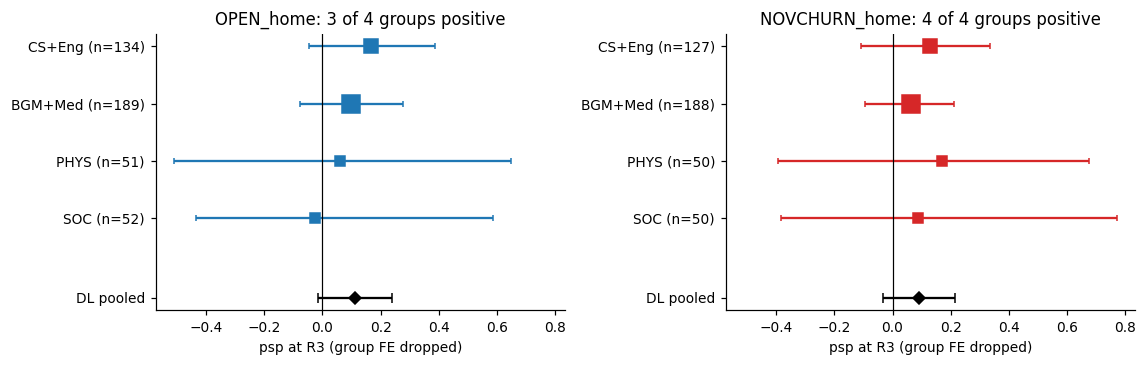

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(10.5, 3.4), sharex=True)
for ax, x, col in ((axs[0], "OPEN_home", C_HOME), (axs[1], "NOVCHURN_home", C_NOV)):
    g = cells[f"groups|{x}|{PRIM}|R3"]
    labs = []
    for i, k in enumerate(g["estimable"]):
        v = g["groups"][k]
        ax.errorbar(v["rho"], i, xerr=[[v["rho"] - v["ci"][0]], [v["ci"][1] - v["rho"]]], fmt="s", color=col,
                    ms=4 + 8 * v["n"] / 200, capsize=2)
        labs.append(f"{k} (n={v['n']})")
    i = len(labs)
    ax.errorbar(g["DL"]["b"], i + .4, xerr=[[g["DL"]["b"] - g["DL"]["ci"][0]], [g["DL"]["ci"][1] - g["DL"]["b"]]],
                fmt="D", color="k", capsize=3)
    labs.append("DL pooled")
    ax.set_yticks(list(range(len(labs) - 1)) + [i + .4], labs); ax.invert_yaxis()
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"{x}: {g['n_positive']} of {g['n_estimable']} groups positive"); ax.set_xlabel("psp at R3 (group FE dropped)")
plt.tight_layout(); plt.show()

**Reading the forest plot.** Three of the four estimable groups are positive. SOC is slightly negative (−0.025) with
a very wide CI (n = 52), so the strict group clause fails. The pooled estimate is close to the overall +0.117, and
I² = 0 means there is no detectable heterogeneity between groups. The failed clause reflects small groups rather than
a group that behaves differently. For `NOVCHURN_home` all 4 estimable groups are positive. LIFEENV (n = 15) and
MATHDEC (n = 7) are too small to estimate.

## Step 7: which component carries the signal?
`OPEN_home` averages six components. The cell below scores each HOME component on its own at R3. The components are
raw, not signed, so a *negative* psp for `ego_density_W3` or `edge_persistence` points in the "open" direction.

In [18]:
t_start = time.time()
for k in COMPONENTS:
    cells[f"comp|{k}__home|{PRIM}|R3"] = psp_df(df, f"{k}__home", PRIM, "R3", N_BOOT_MINOR, SEED)
print(f"component cells in {time.time() - t_start:.0f} s")
comp = pd.DataFrame([{"component": k, "sign in OPEN": oc["home"][k]["sign"], "n": cells[f"comp|{k}__home|{PRIM}|R3"]["n"],
                      "demo psp [CI]": fmt(cells[f"comp|{k}__home|{PRIM}|R3"]),
                      "full-run psp": round(REF["cells"][f"comp|{k}__home|{PRIM}|R3"]["rho"], 3)} for k in COMPONENTS])
comp

component cells in 6 s


,component,sign in OPEN,n,demo psp [CI],full-run psp
0,new_edge_rate,1,465,"+0.035 [-0.052, +0.122]",0.035
1,n_comm_W3,1,465,"+0.069 [-0.030, +0.166]",0.069
2,participation,1,429,"+0.120 [+0.011, +0.223]",0.120
3,NOV_res,1,435,"+0.208 [+0.113, +0.303]",0.208
4,ego_density_W3,-1,396,"-0.078 [-0.182, +0.025]",-0.078
5,edge_persistence,-1,449,"-0.013 [-0.113, +0.083]",-0.013


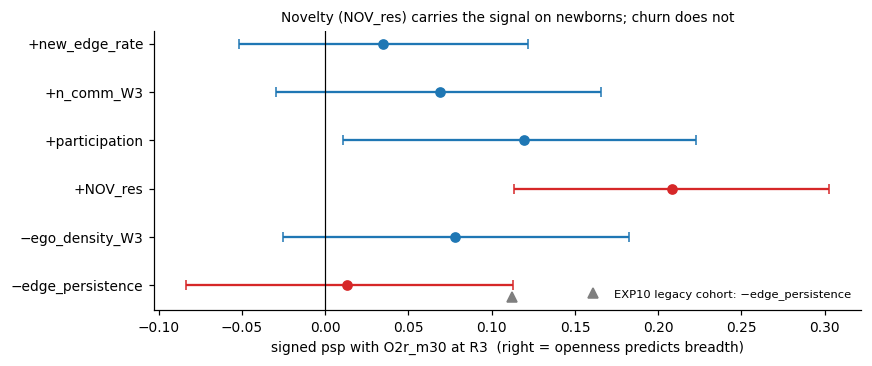

In [19]:
fig, ax = plt.subplots(figsize=(8, 3.4))
for i, k in enumerate(COMPONENTS):
    c = cells[f"comp|{k}__home|{PRIM}|R3"]
    s = oc["home"][k]["sign"]
    col = C_NOV if k in ("NOV_res", "edge_persistence") else C_HOME
    # plot the SIGNED psp (sign x psp) so that right = "more open -> broader" for every component
    ax.errorbar(s * c["rho"], i, xerr=[[s * c["rho"] - min(s * c["ci"][0], s * c["ci"][1])],
                                      [max(s * c["ci"][0], s * c["ci"][1]) - s * c["rho"]]],
                fmt="o", color=col, capsize=3)
ax.plot(REF["exp10_legacy_reference"]["edge_persistence_home_psp"] * -1, COMPONENTS.index("edge_persistence") + .25, "^",
        color=C_GREY, label="EXP10 legacy cohort: −edge_persistence")
ax.set_yticks(range(6), [f"{'−' if oc['home'][k]['sign'] < 0 else '+'}{k}" for k in COMPONENTS]); ax.invert_yaxis()
ax.axvline(0, color="k", lw=.8); ax.legend(frameon=False, fontsize=7.5, loc="lower right")
ax.set_xlabel(f"signed psp with {PRIM} at R3  (right = openness predicts breadth)")
ax.set_title("Novelty (NOV_res) carries the signal on newborns; churn does not", fontsize=9)
plt.tight_layout(); plt.show()

**Reading the components.**
* `NOV_res`, the share of neighbours outside the concept's expected community, is by far the strongest component at
  **+0.21**, with a CI well above 0. `participation`, the spread of neighbours across communities, is the only other
  component whose CI excludes 0 (+0.12).
* `edge_persistence` is null on Frame N (≈ −0.01). On the EXP10 legacy cohort, low persistence was one of the two
  carriers, at −0.112 (grey triangle).
* The paper's reading is that newborn phrases spread when they keep **meeting new partners outside their expected
  community**. How often their partners turn over matters much less.

## Step 8: is the signal mechanical coupling?
One worry is that breadth counts papers in *other* fields, and the ALL-papers build of OPEN also contains off-home
neighbours. OPEN_all could then predict breadth partly by construction. The cell compares the builds with a **paired
bootstrap** on the common sample:
* **ALL − HOME** > 0 would indicate coupling.
* **SIZEMATCH − HOME** isolates the effect of sample size. SIZEMATCH is the ALL build subsampled to the home count.

In [20]:
t_start = time.time()
cells["coupling|all_minus_home|R3"] = paired_diff(df, "OPEN_all", "OPEN_home", PRIM, "R3", N_BOOT, SEED)
cells["coupling|sizematch_minus_home|R3"] = paired_diff(df, "OPEN_sizematch", "OPEN_home", PRIM, "R3", N_BOOT, SEED)
cells[f"clean|n_comm_W3__home|{PRIM}|R3"] = psp_df(df, "n_comm_W3__home", PRIM, "R3", N_BOOT, SEED)
print(f"coupling cells in {time.time() - t_start:.0f} s")
for k in ("coupling|all_minus_home|R3", "coupling|sizematch_minus_home|R3"):
    print(f"{k:36s} n={cells[k]['n']}  demo {fmt(cells[k], 'diff')}   full run {fmt(REF['cells'][k], 'diff')}")

coupling cells in 9 s
coupling|all_minus_home|R3           n=448  demo +0.056 [-0.024, +0.131]   full run +0.056 [-0.024, +0.131]
coupling|sizematch_minus_home|R3     n=447  demo -0.031 [-0.090, +0.029]   full run -0.031 [-0.090, +0.029]


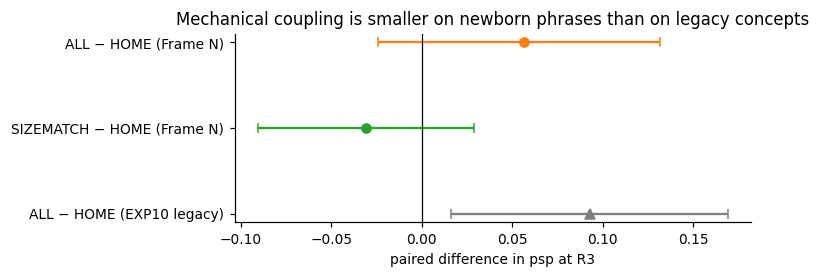

In [21]:
fig, ax = plt.subplots(figsize=(7, 2.6))
rows_ = [("ALL − HOME (Frame N)", cells["coupling|all_minus_home|R3"], C_ALL),
         ("SIZEMATCH − HOME (Frame N)", cells["coupling|sizematch_minus_home|R3"], C_SZ)]
for i, (lab, c, col) in enumerate(rows_):
    ax.errorbar(c["diff"], i, xerr=[[c["diff"] - c["ci"][0]], [c["ci"][1] - c["diff"]]], fmt="o", color=col, capsize=3)
e10 = REF["exp10_legacy_reference"]["all_minus_home"]
ax.errorbar(e10[0], 2, xerr=[[e10[0] - e10[1]], [e10[2] - e10[0]]], fmt="^", color=C_GREY, capsize=3)
ax.set_yticks(range(3), [r[0] for r in rows_] + ["ALL − HOME (EXP10 legacy)"]); ax.invert_yaxis()
ax.axvline(0, color="k", lw=.8); ax.set_xlabel("paired difference in psp at R3")
ax.set_title("Mechanical coupling is smaller on newborn phrases than on legacy concepts")
plt.tight_layout(); plt.show()

The ALL − HOME gap on Frame N is +0.056 and its CI includes 0. On the legacy cohort it was +0.093, with a CI above 0.
SIZEMATCH − HOME is about 0. So the pre-registered **coupling warning is not confirmed**, and the HOME signal is not
an artefact of counting off-home papers.

## Step 9: the Cheng et al. (2023) reversal
Cheng et al. (2023) found that a concept's **ideational consistency** predicts its future *volume*. Consistency is the
cosine similarity of its year-to-year neighbour profiles. The paper pre-registered a **reversal**: the same property
that predicts growth in raw terms should predict staying *local* (less breadth) once size is controlled. The cell
tests three things:
1. raw Spearman of consistency with next-year volume `V_next`;
2. the same association net of log N(t0+2), which checks whether it is only a size effect;
3. psp of consistency with breadth at R0, pre-registered as **negative**.

It also checks how close consistency is to `edge_persistence`.

In [22]:
t_start = time.time()
cells["cheng|CHENG_consistency_home|V_next|raw"] = spearman_boot(df, "CHENG_consistency_home", "V_next", N_BOOT, SEED)
cells["cheng|CHENG_consistency_home|V_next|logN2"] = psp_custom(df, "CHENG_consistency_home", "V_next", ["logN2"], N_BOOT, SEED)
for c in ("CHENG_consistency_home", "CHENG_embeddedness_home"):
    cells[f"cheng|{c}|{PRIM}|R0"] = psp_df(df, c, PRIM, "R0", N_BOOT, SEED, direction=-1)
cells["cheng|consistency_vs_persistence"] = spearman_boot(df, "CHENG_consistency_home", "edge_persistence__home", N_BOOT_MINOR, SEED)
print(f"Cheng cells in {time.time() - t_start:.0f} s")
for k in [k for k in cells if k.startswith("cheng|")]:
    print(f"{k:48s} n={cells[k]['n']}  demo {fmt(cells[k])}   full run {fmt(REF['cells'][k])}")

Cheng cells in 5 s
cheng|CHENG_consistency_home|V_next|raw          n=605  demo +0.418 [+0.345, +0.484]   full run +0.418 [+0.345, +0.484]
cheng|CHENG_consistency_home|V_next|logN2        n=605  demo +0.094 [+0.007, +0.186]   full run +0.094 [+0.007, +0.186]
cheng|CHENG_consistency_home|O2r_m30|R0          n=463  demo -0.064 [-0.159, +0.031]   full run -0.064 [-0.159, +0.031]
cheng|CHENG_embeddedness_home|O2r_m30|R0         n=456  demo -0.250 [-0.328, -0.164]   full run -0.250 [-0.328, -0.164]
cheng|consistency_vs_persistence                 n=580  demo +0.791 [+0.753, +0.826]   full run +0.791 [+0.753, +0.826]


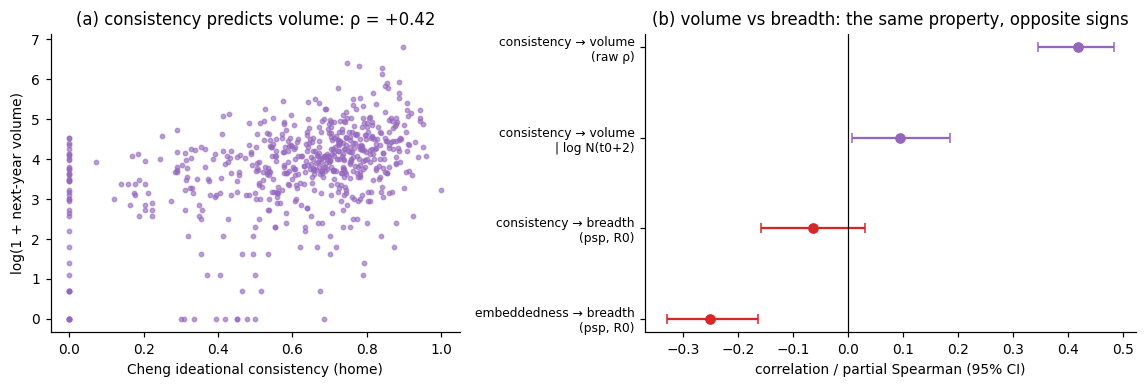

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6), gridspec_kw={"width_ratios": [1, 1.2]})
m = np.isfinite(df.CHENG_consistency_home) & np.isfinite(df.V_next)
ax[0].scatter(df.CHENG_consistency_home[m], np.log1p(df.V_next[m]), s=8, alpha=.6, color=C_CH)
ax[0].set_xlabel("Cheng ideational consistency (home)"); ax[0].set_ylabel("log(1 + next-year volume)")
ax[0].set_title(f"(a) consistency predicts volume: ρ = {cells['cheng|CHENG_consistency_home|V_next|raw']['rho']:+.2f}")
items = [("consistency → volume\n(raw ρ)", "cheng|CHENG_consistency_home|V_next|raw"),
         ("consistency → volume\n| log N(t0+2)", "cheng|CHENG_consistency_home|V_next|logN2"),
         ("consistency → breadth\n(psp, R0)", f"cheng|CHENG_consistency_home|{PRIM}|R0"),
         ("embeddedness → breadth\n(psp, R0)", f"cheng|CHENG_embeddedness_home|{PRIM}|R0")]
for i, (lab, k) in enumerate(items):
    c = cells[k]; col = C_CH if i < 2 else C_NOV
    ax[1].errorbar(c["rho"], i, xerr=[[c["rho"] - c["ci"][0]], [c["ci"][1] - c["rho"]]], fmt="o", color=col, capsize=3)
ax[1].set_yticks(range(len(items)), [l for l, _ in items], fontsize=8); ax[1].invert_yaxis()
ax[1].axvline(0, color="k", lw=.8); ax[1].set_xlabel("correlation / partial Spearman (95% CI)")
ax[1].set_title("(b) volume vs breadth: the same property, opposite signs")
plt.tight_layout(); plt.show()

**Reading the Cheng test.**
* Cheng's result **replicates on its own terms**. Consistency predicts next-year volume, with raw ρ = +0.42, and the
  association survives the size control at +0.094.
* **Net of size, consistency points toward staying local.** Its psp with breadth is −0.064. That CI includes 0, so
  the pre-registered REVERSAL is *not confirmed*.
* Cheng's *embeddedness* analogue is clearly negative with breadth, at −0.25.
* Consistency is essentially a weighted edge persistence (ρ ≈ +0.79 with `edge_persistence__home`). This is why the
  paper treats it as the "closed" end of the same axis that `OPEN_home` measures from the "open" end.

## Step 10: Holm correction and the pre-registered verdict (`lib/scoring.py`)
The **Holm family** has five members:
* OPEN_home at R3;
* OPEN_home at R5;
* NOVCHURN_home at R3;
* Cheng consistency at R0 (< 0);
* the ALL − HOME coupling.

`verdict()` is the pre-registered decision code, written before the unseal. It is copied unchanged, with only the
cells it needs filled in above.
* **CONFIRMED** requires OPEN_home CI > 0 at R3 *and* R5, the group clause, *and* NOVCHURN_home CI > 0 at R3.
* **PARTIAL** requires at least one of the two R3 clauses.
* A CONFIRMED verdict is capped at PARTIAL if pre-unseal power was < 0.5. The full run's joint power was 0.47.

In [24]:
def verdict(res: dict, prim: str, power_joint: float | None) -> dict:
    L = res["cells"]
    o3, o5 = L[f"ladder|OPEN_home|{prim}|R3"], L[f"ladder|OPEN_home|{prim}|R5"]
    nv3 = L[f"ladder|NOVCHURN_home|{prim}|R3"]
    grp = L[f"groups|OPEN_home|{prim}|R3"]
    ne, npos = grp["n_estimable"], grp["n_positive"]
    if ne >= 5:
        gclause, geval = npos >= 4, True
    elif ne == 4:
        gclause, geval = npos == 4, True
    else:
        gclause, geval = False, False
    c = {"open_home_R3_ci_gt0": bool(o3["ci"][0] > 0), "open_home_R5_ci_gt0": bool(o5["ci"][0] > 0),
         "group_clause": bool(gclause), "group_clause_evaluable": geval,
         "novchurn_R3_ci_gt0": bool(nv3["ci"][0] > 0)}
    if c["open_home_R3_ci_gt0"] and c["open_home_R5_ci_gt0"] and gclause and c["novchurn_R3_ci_gt0"]:
        v = "CONFIRMED"
    elif c["open_home_R3_ci_gt0"] or c["novchurn_R3_ci_gt0"]:
        v = "PARTIAL"
    else:
        v = "NOT CONFIRMED"
    caps = []
    if v == "CONFIRMED" and not geval:
        v, _ = "PARTIAL", caps.append("group clause not evaluable (<= 3 estimable groups)")
    if v == "CONFIRMED" and power_joint is not None and power_joint < 0.5:
        v, _ = "PARTIAL", caps.append(f"pre-unseal power {power_joint:.2f} < 0.5")
    hp = res["holm"]
    fam = list(hp.keys())
    confirmed_holm = all(hp[k]["p_holm"] < 0.05 for k in fam[:3])
    ch_raw = L["cheng|CHENG_consistency_home|V_next|raw"]
    ch_o2 = L[f"cheng|CHENG_consistency_home|{prim}|R0"]
    ch_sz = L["cheng|CHENG_consistency_home|V_next|logN2"]
    reversal = bool(ch_raw["ci"][0] > 0 and ch_o2["ci"][1] < 0)
    fails_as_size = bool(ch_sz["ci"][0] <= 0 <= ch_sz["ci"][1])
    cp = L["coupling|all_minus_home|R3"]
    nc = L[f"clean|n_comm_W3__home|{prim}|R3"]
    coupling = bool(cp["ci"][0] > 0 and nc["ci"][0] <= 0 <= nc["ci"][1])
    return {"verdict": v, "clauses": c, "caps": caps, "n_estimable_groups": ne, "n_positive_groups": npos,
            "CONFIRMED_HOLM": bool(confirmed_holm),
            "reversal": {"REVERSAL_CONFIRMED": reversal, "raw_rho_V_next": ch_raw["rho"], "raw_ci": ch_raw["ci"],
                         f"psp_{prim}_R0": ch_o2["rho"], f"psp_{prim}_R0_ci": ch_o2["ci"],
                         "REVERSAL_FAILS_AS_SIZE": fails_as_size, "psp_V_next_given_logN2": ch_sz["rho"],
                         "psp_V_next_given_logN2_ci": ch_sz["ci"],
                         "statement": ("Cheng consistency effect is a size effect" if fails_as_size else
                                       "Cheng consistency effect on V_next survives the size control")},
            "coupling": {"COUPLING_WARNING_CONFIRMED": coupling, "all_minus_home": cp["diff"],
                         "all_minus_home_ci": cp["ci"], "n_comm_W3_home_psp": nc["rho"], "n_comm_W3_home_ci": nc["ci"]}}


def holm_table(cells: dict, prim: str) -> dict:
    fam = [(f"OPEN_home|{prim}|R3", cells[f"ladder|OPEN_home|{prim}|R3"]["p_one"]),
           (f"OPEN_home|{prim}|R5", cells[f"ladder|OPEN_home|{prim}|R5"]["p_one"]),
           (f"NOVCHURN_home|{prim}|R3", cells[f"ladder|NOVCHURN_home|{prim}|R3"]["p_one"]),
           (f"CHENG_consistency_home|{prim}|R0 (<0)", cells[f"cheng|CHENG_consistency_home|{prim}|R0"]["p_one"]),
           (f"OPEN_all-OPEN_home|{prim}|R3 paired", cells["coupling|all_minus_home|R3"]["p_one"])]
    ph = holm([p for _, p in fam])
    return {k: {"p_one": p, "p_holm": h} for (k, p), h in zip(fam, ph)}

In [25]:
res_demo = {"cells": cells}
res_demo["holm"] = holm_table(cells, PRIM)
V = verdict(res_demo, PRIM, power_joint=0.47)   # pre-unseal joint power from results/power.json
print("VERDICT (demo):", V["verdict"], "   | full run:", REF["verdicts"]["verdict"], "\n")
print(pd.DataFrame({"demo": V["clauses"], "full run": REF["verdicts"]["clauses"]}), "\n")
hol = pd.DataFrame([{"test": k, "p one-sided": v["p_one"], "p Holm": v["p_holm"],
                     "full-run p Holm": REF["holm"][k]["p_holm"]} for k, v in res_demo["holm"].items()])
print("CONFIRMED_HOLM:", V["CONFIRMED_HOLM"], "| REVERSAL_CONFIRMED:", V["reversal"]["REVERSAL_CONFIRMED"],
      "| COUPLING_WARNING_CONFIRMED:", V["coupling"]["COUPLING_WARNING_CONFIRMED"])
hol.round(4)

VERDICT (demo): PARTIAL    | full run: PARTIAL 

                         demo  full run
open_home_R3_ci_gt0      True      True
open_home_R5_ci_gt0     False     False
group_clause            False     False
group_clause_evaluable   True      True
novchurn_R3_ci_gt0       True      True 

CONFIRMED_HOLM: False | REVERSAL_CONFIRMED: False | COUPLING_WARNING_CONFIRMED: False


,test,p one-sided,p Holm,full-run p Holm
0,OPEN_home|O2r_m30|R3,0.0105,0.0525,0.0525
1,OPEN_home|O2r_m30|R5,0.0375,0.1124,0.1124
2,NOVCHURN_home|O2r_m30|R3,0.0215,0.0860,0.0860
3,CHENG_consistency_home|O2r_m30|R0 (<0),0.0985,0.1889,0.1889
4,OPEN_all-OPEN_home|O2r_m30|R3 paired,0.0945,0.1889,0.1889


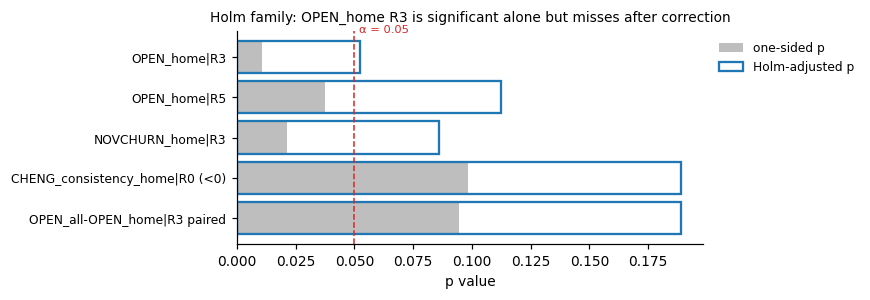

In [26]:
fig, ax = plt.subplots(figsize=(8, 2.8))
for i, (k, v) in enumerate(res_demo["holm"].items()):
    ax.barh(i, v["p_one"], color=C_GREY, alpha=.5, label="one-sided p" if i == 0 else None)
    ax.barh(i, v["p_holm"], color="none", edgecolor=C_HOME, lw=1.5, label="Holm-adjusted p" if i == 0 else None)
ax.axvline(0.05, color=C_NOV, ls="--", lw=1); ax.text(0.052, -0.6, "α = 0.05", color=C_NOV, fontsize=7.5)
ax.set_yticks(range(5), [k.replace(f"|{PRIM}", "") for k in res_demo["holm"]], fontsize=8); ax.invert_yaxis()
ax.set_xlabel("p value"); ax.legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set_title("Holm family: OPEN_home R3 is significant alone but misses after correction", fontsize=9)
plt.tight_layout(); plt.show()

## Step 11: does openness improve forecasts?
A signal can be real and still useless for prediction. Both models below were **fitted on EXP5 legacy concepts and
frozen**: one uses B5 alone and one uses B5 + OPEN_home. The cell compares their Spearman correlation with realised
breadth on Frame N. The point estimates match the full run exactly. The bootstrap CI of the gain can differ from the
full run's in the third decimal, because this cell draws its own resampling stream.

n = 448   Spearman B5 = 0.804   B5 + OPEN_home = 0.809   gain = +0.0047 [-0.0010, +0.0105]
full run:      B5 = 0.804   B5 + OPEN_home = 0.809   gain = +0.0047 [-0.0012, +0.0112]


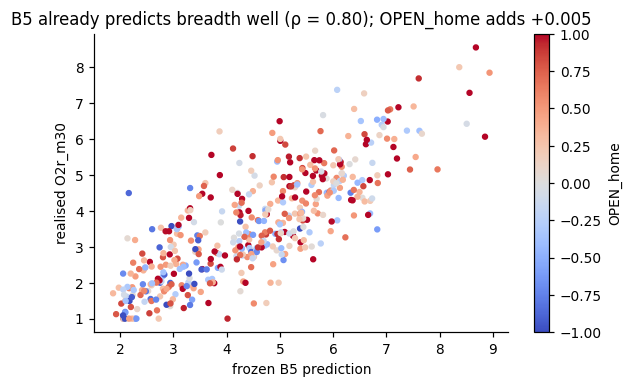

In [27]:
d = df[np.isfinite(df[PRIM]) & np.isfinite(df.pred_b5) & np.isfinite(df.pred_b5_open)]
y_, p0, p1 = d[PRIM].to_numpy(), d.pred_b5.to_numpy(), d.pred_b5_open.to_numpy()
rng = np.random.default_rng(SEED)
bs = []
for _ in range(N_BOOT):
    i = rng.integers(0, len(y_), len(y_))
    bs.append(stats.spearmanr(p1[i], y_[i])[0] - stats.spearmanr(p0[i], y_[i])[0])
s0, s1 = stats.spearmanr(p0, y_)[0], stats.spearmanr(p1, y_)[0]
ff = REF["forecast_frozen_exp5"]
print(f"n = {len(d)}   Spearman B5 = {s0:.3f}   B5 + OPEN_home = {s1:.3f}   gain = {s1 - s0:+.4f} "
      f"[{np.percentile(bs, 2.5):+.4f}, {np.percentile(bs, 97.5):+.4f}]")
print(f"full run:      B5 = {ff['spearman_B5']:.3f}   B5 + OPEN_home = {ff['spearman_B5_plus_OPEN_home']:.3f}   "
      f"gain = {ff['diff']:+.4f} [{ff['diff_ci'][0]:+.4f}, {ff['diff_ci'][1]:+.4f}]")
fig, ax = plt.subplots(figsize=(5.5, 3.6))
sc = ax.scatter(d.pred_b5, d[PRIM], c=d.OPEN_home, cmap="coolwarm", s=10, vmin=-1, vmax=1)
plt.colorbar(sc, label="OPEN_home")
ax.set_xlabel("frozen B5 prediction"); ax.set_ylabel(f"realised {PRIM}")
ax.set_title(f"B5 already predicts breadth well (ρ = {s0:.2f}); OPEN_home adds {s1 - s0:+.3f}")
plt.tight_layout(); plt.show()

## Illustration: matched high- and low-churn pairs
The full run printed matched pairs as an illustration only, not as evidence. The two phrases in a pair come from the
same group and have near-identical B5-predicted breadth. One is in the top quintile of `NOVCHURN_home` and the other
in the bottom quintile. The pairs show what the index looks like on real phrases.

In [28]:
pd.DataFrame([{"group": p["group"],
               "high-churn phrase": p["high_churn"]["name"], "NOVCHURN hi": round(p["high_churn"]["NOVCHURN_home"], 2),
               f"{PRIM} hi": round(p["high_churn"]["O2r_m30"], 2),
               "low-churn phrase": p["low_churn"]["name"], "NOVCHURN lo": round(p["low_churn"]["NOVCHURN_home"], 2),
               f"{PRIM} lo": round(p["low_churn"]["O2r_m30"], 2)} for p in data["case_pairs"]])

,group,high-churn phrase,NOVCHURN hi,O2r_m30 hi,low-churn phrase,NOVCHURN lo,O2r_m30 lo
0,BGM+Med,detrusor overactivity,0.25,1.49,liver partition,-1.34,1.83
1,PHYS,tev pp collisions,0.50,1.00,fermi large area,-1.67,1.00
2,BGM+Med,xuebijing injection,0.33,3.80,single port access,-1.75,4.64
3,CS+Eng,rfid system,0.46,3.73,material for sodium,-1.20,3.18
4,CS+Eng,unmanned aircraft,0.51,5.95,anode for sodium,-1.20,3.38
5,PHYS,direct aldol,0.21,2.52,shrimp zircon,-1.49,2.48


## Summary: demo vs full run
The table puts every headline number recomputed in this notebook next to the frozen full-run value in
`results/frame_n_result.json`. The demo uses the same data, code, seed and number of draws, so the point estimates
and CIs should agree to floating-point precision.

In [29]:
keys = [f"ladder|OPEN_home|{PRIM}|R3", f"ladder|OPEN_home|{PRIM}|R5", f"ladder|NOVCHURN_home|{PRIM}|R3",
        "ladder|OPEN_home|O2r_m50|R3", f"comp|NOV_res__home|{PRIM}|R3", f"comp|edge_persistence__home|{PRIM}|R3",
        "coupling|all_minus_home|R3", "coupling|sizematch_minus_home|R3",
        "cheng|CHENG_consistency_home|V_next|raw", f"cheng|CHENG_consistency_home|{PRIM}|R0"]
summ = []
for k in keys:
    est = "diff" if k.startswith("coupling") else "rho"
    summ.append({"quantity": k, "demo": fmt(cells[k], est), "full run": fmt(REF["cells"][k], est),
                 "|Δ estimate|": abs(cells[k][est] - REF["cells"][k][est]),
                 "|Δ CI|": max(abs(a - b) for a, b in zip(cells[k]["ci"], REF["cells"][k]["ci"]))})
g_ = cells[f"groups|OPEN_home|{PRIM}|R3"]["DL"]; gR = REF["cells"][f"groups|OPEN_home|{PRIM}|R3"]["DL"]
summ.append({"quantity": "DL pooled OPEN_home R3", "demo": f"{g_['b']:+.3f} [{g_['ci'][0]:+.3f}, {g_['ci'][1]:+.3f}]",
             "full run": f"{gR['b']:+.3f} [{gR['ci'][0]:+.3f}, {gR['ci'][1]:+.3f}]",
             "|Δ estimate|": abs(g_["b"] - gR["b"]), "|Δ CI|": max(abs(a - b) for a, b in zip(g_["ci"], gR["ci"]))})
summ.append({"quantity": "VERDICT", "demo": V["verdict"], "full run": REF["verdicts"]["verdict"],
             "|Δ estimate|": np.nan, "|Δ CI|": np.nan})
S = pd.DataFrame(summ)
print("max |Δ estimate| =", f"{S['|Δ estimate|'].max():.1e}", "  max |Δ CI| =", f"{S['|Δ CI|'].max():.1e}")
S

max |Δ estimate| = 1.4e-16   max |Δ CI| = 2.2e-16


,quantity,demo,full run,|Δ estimate|,|Δ CI|
0,ladder|OPEN_home|O2r_m30|R3,"+0.117 [+0.020, +0.218]","+0.117 [+0.020, +0.218]",5.551115e-17,5.551115e-17
1,ladder|OPEN_home|O2r_m30|R5,"+0.086 [-0.009, +0.190]","+0.086 [-0.009, +0.190]",9.714451e-17,1.110223e-16
2,ladder|NOVCHURN_home|O2r_m30|R3,"+0.108 [+0.007, +0.211]","+0.108 [+0.007, +0.211]",1.387779e-17,8.326673e-17
3,ladder|OPEN_home|O2r_m50|R3,"+0.161 [+0.064, +0.263]","+0.161 [+0.064, +0.263]",2.775558e-17,2.220446e-16
4,comp|NOV_res__home|O2r_m30|R3,"+0.208 [+0.113, +0.303]","+0.208 [+0.113, +0.303]",0.000000e+00,5.551115e-17
5,comp|edge_persistence__home|O2r_m30|R3,"-0.013 [-0.113, +0.083]","-0.013 [-0.113, +0.083]",1.734723e-18,5.551115e-17
6,coupling|all_minus_home|R3,"+0.056 [-0.024, +0.131]","+0.056 [-0.024, +0.131]",1.387779e-16,2.220446e-16
7,coupling|sizematch_minus_home|R3,"-0.031 [-0.090, +0.029]","-0.031 [-0.090, +0.029]",5.551115e-17,9.714451e-17
8,cheng|CHENG_consistency_home|V_next|raw,"+0.418 [+0.345, +0.484]","+0.418 [+0.345, +0.484]",0.000000e+00,0.000000e+00
9,cheng|CHENG_consistency_home|O2r_m30|R0,"-0.064 [-0.159, +0.031]","-0.064 [-0.159, +0.031]",6.938894e-17,2.775558e-17


## Takeaways
* **Direction replicates, strength is marginal.** On a population that no step of the project had scored, and that
  lies outside every curated vocabulary, early home-field openness is positively associated with later cross-field
  breadth after controlling for size, growth, reach, type and footprint. The estimate is OPEN_home psp +0.117 at R3,
  larger than the +0.080 on the legacy cohort.
* The pre-registered verdict is **PARTIAL**, not CONFIRMED, for three reasons:
  * the R5 CI touches 0;
  * one small group (SOC) is negative, so the strict group clause fails;
  * after Holm correction the headline p is 0.052.
* **Novelty, not churn.** On newborn phrases the signal is carried by `NOV_res`, meaning new partners outside the
  expected community. Partner turnover (`edge_persistence`) contributes nothing.
* **Not an artefact.** The coupling gap is small and not significant, and shuffled-outcome placebos stay below the
  observed estimate.
* **Not a forecasting tool.** Adding OPEN_home to B5 improves the Spearman by only +0.005. The finding is about *how*
  concepts spread, not a better predictor of *how far*.
* **Cheng et al.:** consistency predicts volume, and net of size it leans toward staying local. That lean is not
  significant for breadth, but it is significant for sustained uptake and strong for embeddedness.